In [3]:
# imports
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import files

In [2]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [10]:
def load_data(file_name):
    """Load the data"""
    uploaded_files = files.upload()
    data = pd.read_csv(f'{file_name}.csv')
    return data

In [14]:
def create_dashboard(processed_data, timing_data, payment_methods):
    """Create comprehensive visualization dashboard"""

    # Load data
    df = processed_data

    # Create figure with subplots
    fig = plt.figure(figsize=(15, 10))

    # 1. Payment Status Distribution
    ax1 = plt.subplot(2, 3, 1)
    status_counts = df['payment_class'].value_counts()
    colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    status_counts.plot(kind='bar', ax=ax1, color=colors)
    ax1.set_title('Payment Status Distribution', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Status')
    ax1.set_ylabel('Number of Orders')
    ax1.tick_params(axis='x', rotation=45)

    # 2. Payment Amount Distribution
    ax2 = plt.subplot(2, 3, 2)
    fully_paid = df[df['payment_class'] == 'Complete']['total_amount']
    ax2.hist(fully_paid, bins=30, alpha=0.7, label='Fully Paid', color='#2ecc71')
    ax2.hist(df['total_amount'], bins=30, alpha=0.5, label='All Orders', color='#3498db')
    ax2.set_title('Order Value Distribution', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Amount (USD)')
    ax2.set_ylabel('Frequency')
    ax2.legend()

    # 3. Payment Rate Analysis
    ax3 = plt.subplot(2, 3, 3)
    payment_rates = df[df['total_paid'] > 0]['payment_rate']
    ax3.hist(payment_rates, bins=30, edgecolor='black', alpha=0.7, color='#9b59b6')
    ax3.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Full Payment')
    ax3.set_title('Payment Rate Distribution', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Payment Rate (Paid/Total)')
    ax3.set_ylabel('Frequency')
    ax3.legend()

    # 4. Payment Timing Analysis
    ax4 = plt.subplot(2, 3, 4)
    if 'days_to_first_payment' in df.columns:
        # timing_data = pd.read_csv('../outputs/reports/payment_schedule.csv')
        timing_data = timing_data
        ax4.hist(timing_data['days_to_first_payment'], bins=20, edgecolor='black', alpha=0.7)
        ax4.set_title('Days to First Payment', fontsize=12, fontweight='bold')
        ax4.set_xlabel('Days After Order')
        ax4.set_ylabel('Number of Orders')
    else:
        ax4.text(0.5, 0.5, 'Run payment schedule analysis first',
                ha='center', va='center', transform=ax4.transAxes)

    # 5. Payment Methods
    ax5 = plt.subplot(2, 3, 5)
    # payment_methods = pd.read_csv('../data/raw/payments.csv')
    payment_methods = payment_methods
    method_counts = payment_methods['payment_method'].value_counts()
    method_counts.plot(kind='pie', autopct='%1.1f%%', ax=ax5, startangle=90)
    ax5.set_title('Payment Methods Distribution', fontsize=12, fontweight='bold')
    ax5.set_ylabel('')

    # 6. Risk Analysis
    ax6 = plt.subplot(2, 3, 6)
    risk_data = df.groupby('high_risk')['total_amount'].sum()
    risk_labels = ['Low Risk', 'High Risk']
    colors_risk = ['#2ecc71', '#e74c3c']
    risk_data.plot(kind='bar', ax=ax6, color=colors_risk)
    ax6.set_title('Order Value by Risk Level', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Risk Level')
    ax6.set_ylabel('Total Order Value (USD)')
    ax6.tick_params(axis='x', rotation=0)

    plt.suptitle('Order-Payment Reconciliation Dashboard', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    # plt.savefig('../outputs/visualizations/reconciliation_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Dashboard saved to: outputs/visualizations/reconciliation_dashboard.png")

In [12]:
processed_data = load_data("reconciliation_advanced")     # Load processed data
timing_data = load_data("payment_schedule")               # Load payment_schedule data
payment_methods = load_data("payments")                   # Load payments data

Saving reconciliation_advanced.csv to reconciliation_advanced (2).csv


Saving payment_schedule.csv to payment_schedule.csv


Saving payments.csv to payments.csv


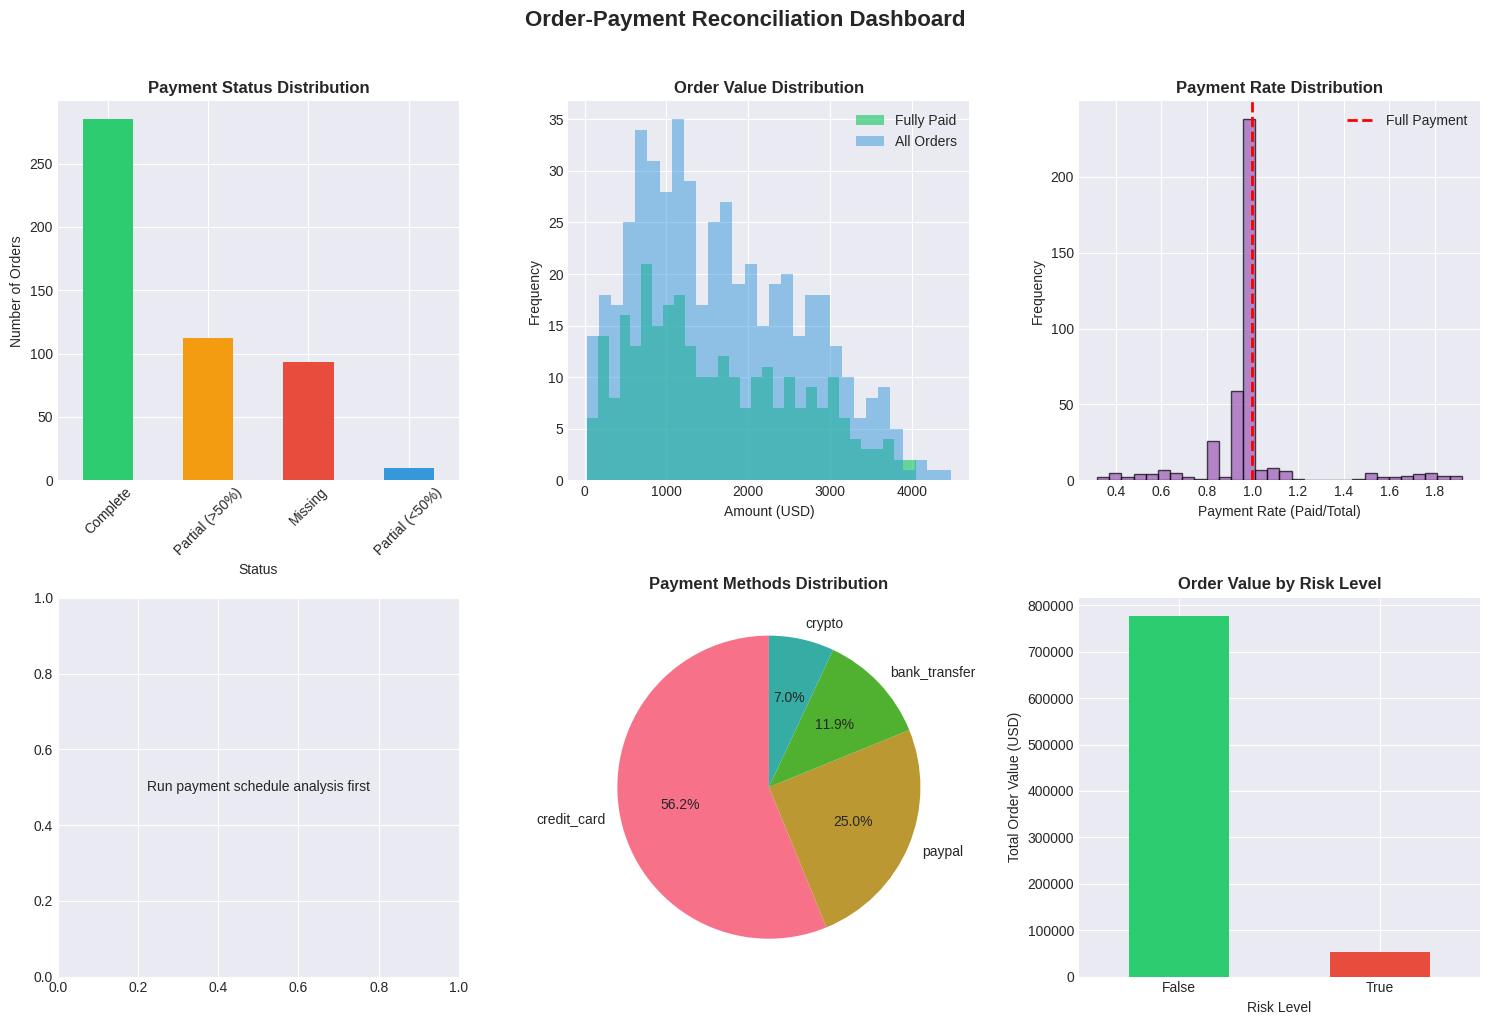

Dashboard saved to: outputs/visualizations/reconciliation_dashboard.png


In [15]:
# Create the dashboard
create_dashboard(processed_data, timing_data, payment_methods)